# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

### Objective: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

### Dataset: This lab utilizes the Amazon UK product dataset which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

<br>

### Part 1: Understanding Product Categories
### Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

### Frequency Tables:

### - Generate a frequency table for the product category.
### - Which are the top 5 most listed product categories?

<br>

### Visualizations:

### - Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
### - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
path = "C:/Users/ferna/OneDrive/Desktop/Fernando/Ironhack/DSML/Week_2/lab-eda-univariate/archive/amz_uk_price_prediction_dataset.csv"
raw_data = pd.read_csv(path)

In [4]:
df = raw_data.copy()

In [5]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
df["boughtInLastMonth"].nunique()

25

In [7]:
df["category"].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [8]:
category_frecuency = df["category"].value_counts()


top_5_category = (df["category"].value_counts().head(5).reset_index())

In [9]:
top_5_category.columns = ["category", "frequency"]

In [10]:
top_5_category

,category,frequency
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978


C:\Users\ferna\AppData\Local\Temp\ipykernel_11056\290551503.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_category, y="category", x="frequency", palette="magma")


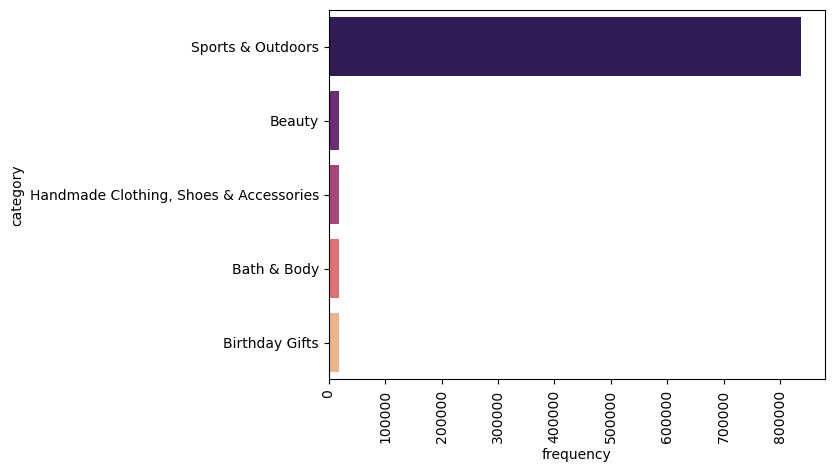

In [11]:
sns.barplot(data=top_5_category, y="category", x="frequency", palette="magma")
plt.xticks(rotation=90)
plt.show()

In [12]:
df["category"].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [13]:
df["category"].nunique()

296

In [14]:
category_counts = df["category"].value_counts()

new_categories = (category_counts.iloc[1:6].reset_index())

new_categories.columns = ["category", "frequency"]

new_categories

,category,frequency
0,Beauty,19312
1,"Handmade Clothing, Shoes & Accessories",19229
2,Bath & Body,19092
3,Birthday Gifts,18978
4,Manicure & Pedicure Products,18940


C:\Users\ferna\AppData\Local\Temp\ipykernel_11056\1084539004.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=new_categories, y="category", x="frequency", palette="magma")


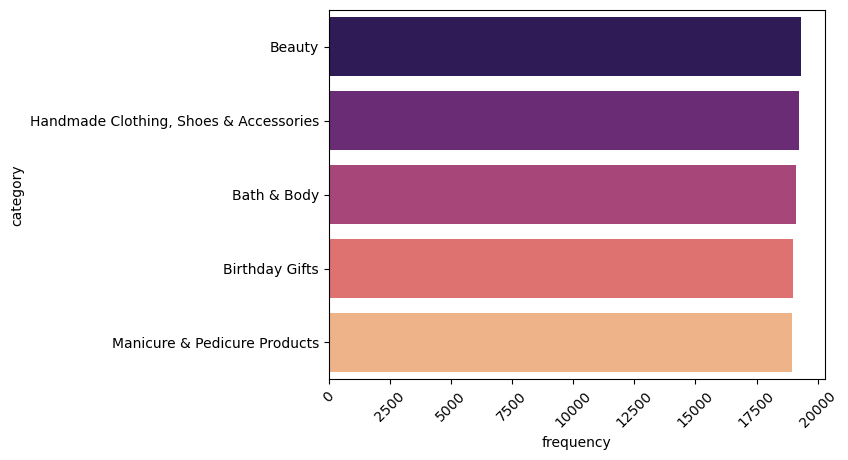

In [15]:
sns.barplot(data=new_categories, y="category", x="frequency", palette="magma")
plt.xticks(rotation=45)
plt.show()

In [16]:
category_frecuency = df["category"].value_counts()


top_6_category = (df["category"].value_counts().head(6).reset_index())

top_6_category.columns = ["category", "frequency"]

top_6_category

,category,frequency
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
5,Manicure & Pedicure Products,18940


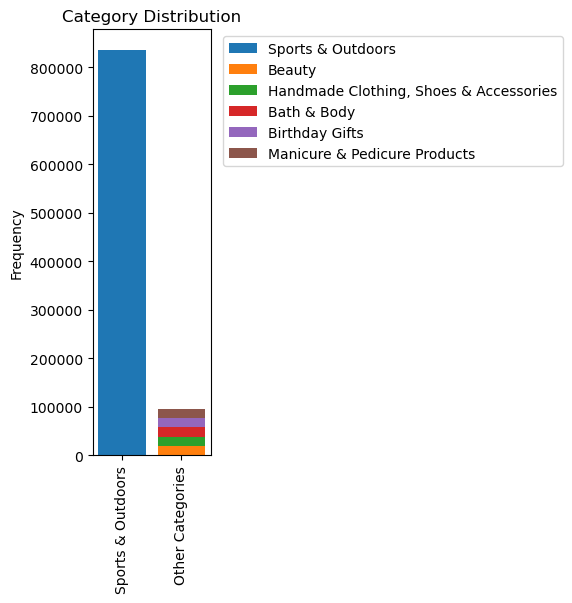

In [17]:
# First category
top_category = top_6_category.iloc[0]

# Remaining categories
other_categories = top_6_category.iloc[1:]

plt.figure(figsize=(6, 5))

# Bar 1: Sports & Outdoors
plt.bar("Sports & Outdoors", top_category["frequency"], label=top_category["category"])

# Bar 2: stacked categories
bottom = 0
colors = plt.cm.tab10.colors  # distinct colors

for i, row in other_categories.iterrows():
    plt.bar("Other Categories", row["frequency"], bottom=bottom, label=row["category"], color=colors[i % len(colors)])
    bottom += row["frequency"]

plt.ylabel("Frequency")
plt.title("Category Distribution")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

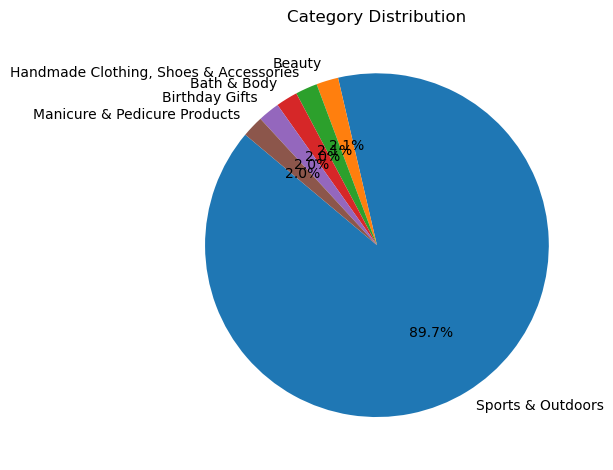

In [18]:
# Assuming top_6_category is your DataFrame
plt.pie(
    top_6_category["frequency"], 
    labels=top_6_category["category"], 
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Category Distribution")
plt.tight_layout()
plt.savefig('category_pie_chart.png')

### Part 2: Delving into Product Pricing
### Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

### 1. Measures of Centrality:

### - Calculate the mean, median, and mode for the price of products.
### - What's the average price point of products listed? How does this compare with the most common price point (mode)?

### 2. Measures of Dispersion:

### - Determine the variance, standard deviation, range, and interquartile range for product price.
### - How varied are the product prices? Are there any indicators of a significant spread in prices?
### 3. Visualizations:

### - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
### - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

In [19]:
round(df.describe(), 2)

,uid,stars,reviews,price,boughtInLastMonth
count,2443651.00,2443651.00,2443651.00,2443651.00,2443651.00
mean,1370545.35,2.15,480.63,89.24,25.90
std,816056.17,2.19,5944.12,345.61,240.48
min,1.00,0.00,0.00,0.00,0.00
25%,658921.50,0.00,0.00,9.99,0.00
50%,1349029.00,0.00,0.00,19.09,0.00
75%,2060685.50,4.40,59.00,45.99,0.00
max,2828593.00,5.00,1356658.00,100000.00,50000.00


In [20]:
price_mean = round(df["price"].mean(), 2)
price_meadian = round(df["price"].median(), 2)
price_mode = df["price"].mode()[0]

print(price_mean)
print(price_meadian)
print(price_mode)

89.24
19.09
9.99


In [21]:
dif_mean_mode = price_mean - price_mode

print(f"The average product price is: £{price_mean}")
print(f"The most repeated price is: £{price_mode}")
print(f"The difference between the average price and the most common price is: £{dif_mean_mode}")


The average product price is: £89.24
The most repeated price is: £9.99
The difference between the average price and the most common price is: £79.25


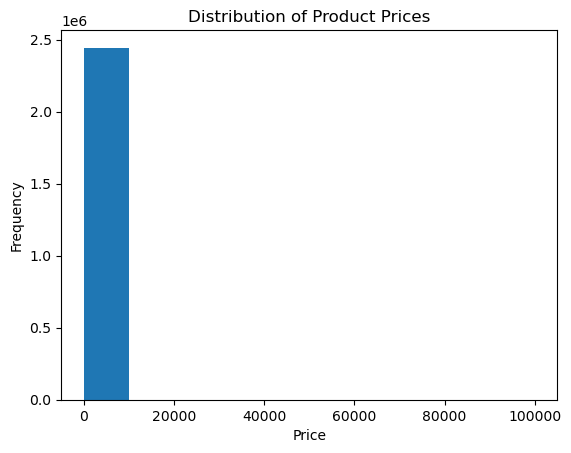

In [22]:
plt.hist(df["price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices")
plt.show()

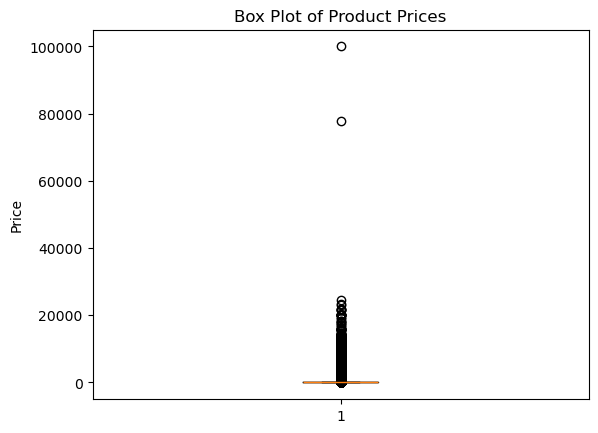

In [23]:
plt.boxplot(df["price"])
plt.ylabel("Price")
plt.title("Box Plot of Product Prices")
plt.savefig("price_boxplot.png")

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [24]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [25]:
df["stars"].mean()

2.152836472966065

In [26]:
df["stars"].median()

0.0

In [27]:
df["stars"].mode()

0    0.0
Name: stars, dtype: float64

In [28]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [29]:
df_reviews = df[df["stars"] > 0]

In [31]:
df_reviews["stars"].mean()

4.31916076222691

In [32]:
df_reviews["stars"].median()

4.4

In [33]:
df_reviews["stars"].mode()

0    4.5
Name: stars, dtype: float64

In [34]:
df_reviews.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,1.218010e+06,1.218010e+06,1.218010e+06,1.218010e+06,1.218010e+06
mean,1.397794e+06,4.319161e+00,9.642667e+02,4.531353e+01,5.181928e+01
std,8.420525e+05,5.552868e-01,8.391678e+03,1.288102e+02,3.384423e+02
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,6.905842e+05,4.100000e+00,9.000000e+00,8.990000e+00,0.000000e+00
50%,1.390506e+06,4.400000e+00,6.000000e+01,1.697000e+01,0.000000e+00
75%,2.126020e+06,4.600000e+00,3.600000e+02,3.485000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.999000e+04,5.000000e+04


In [35]:
stars_skew = df_reviews["stars"].skew()
stars_kurt = df_reviews["stars"].kurt()

print(f"Skewness: {stars_skew:.3f}")
print(f"Kurtosis: {stars_kurt:.3f}")

Skewness: -2.380
Kurtosis: 9.782


([<matplotlib.axis.XTick at 0x2291a498e90>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

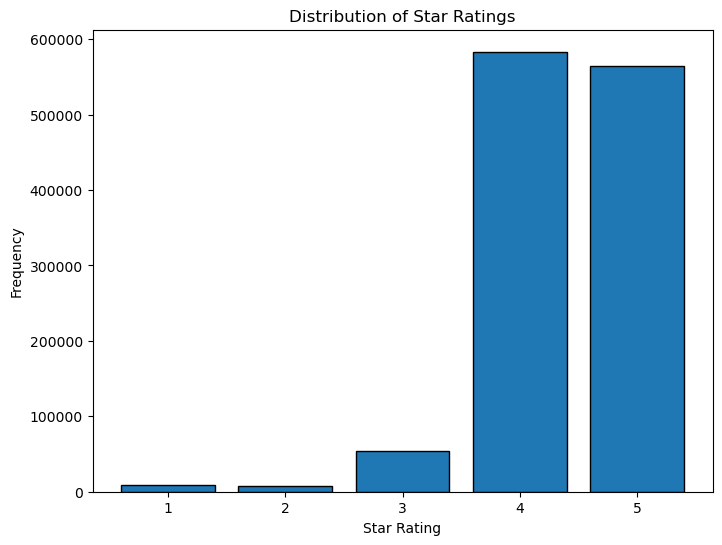

In [37]:
plt.figure(figsize=(8, 6))

# Using bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5] centers the bars on the ratings 1 through 5
plt.hist(df_reviews["stars"], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', rwidth=0.8)

plt.xlabel("Star Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Star Ratings")
plt.xticks([1, 2, 3, 4, 5])